In [1]:
import hoda
import tensorly as tl

print(tl.get_backend())
%pip freeze | grep moabb

cupy
moabb==0.4.6
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
       #BI2012(),
       #BI2013a(),
       #BI2014a(),
       #BI2014b(),
       #BI2015a(),
       #BI2015b(),
       BNCI2014008(),
       BNCI2014009(),
       #BNCI2015_003(),
       #Cattan2019_VR(),
       #EPFLP300(),
       #Huebner2017(),
       #Huebner2018(),
       #Lee2019_ERP(),
       #Sosulski2019()   
   ]



In [3]:
from sklearn.pipeline import Pipeline
from mne.decoding import Scaler
from hoda.hoda import  BTTDA
from hoda.classification import Vectorize
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold

pipeline = Pipeline([
    ('bttda', BTTDA(
        n_blocks=32,
        hoda_params=dict(
            rank=None,
            max_iter=1000,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
            prune=True,
        ),
        verbose=False,
    )),
    ('vec', Vectorize()),
    ('z_score', StandardScaler()),
    ('lda',LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))
])

cv = StratifiedKFold(n_splits=5)

In [4]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

def evaluate_fold(dataset, run, X, labels, fold, train_idc, test_idc):
    train_idc = run_idc[train_idc]
    test_idc = run_idc[test_idc]
    pipeline[0].fit(X[train_idc], labels[train_idc])
    results = []
    for n_blocks in range(1, pipeline[0].n_blocks+1): 
        Xt_train = pipeline[0].transform(X[train_idc], n_blocks=n_blocks)
        Xt_test = pipeline[0].transform(X[test_idc], n_blocks=n_blocks)
        pipeline[1:].fit(Xt_train, labels[train_idc])
        pred = pipeline[1:].decision_function(Xt_test)
        score = roc_auc_score(labels[test_idc], pred)
        results.append(dict(
            dataset=dataset.code,
            subject=run[0],
            session=run[1],
            fold=fold,
            n_blocks=n_blocks,
            roc_auc_score=score
        ))
    return results

df = []
for dataset in datasets:
    X, labels, meta = paradigm.get_data(dataset, subjects=[1])
    idc = meta.reset_index()\
        .groupby(['subject', 'session'])\
        .index.aggregate(list)
    for run, run_idc in idc.items():
        print(dataset.code + ' ' + str(run))
        run_idc = np.array(run_idc)    
        fold_results = Parallel(n_jobs=cv.n_splits)\
            (delayed(evaluate_fold)(dataset, run, X, labels, fold, train_idc, test_idc)\
             for fold, (train_idc, test_idc) in enumerate(cv.split(X[run_idc], labels[run_idc])))
        df += fold_results


df = pd.DataFrame([item for sublist in df for item in sublist])

008-2014 (1, 'session_0')


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/p300.py:181: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X.append(dataset.unit_factor * epochs.get_data())


Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [2, 2] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [3, 3] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...

/usr/local/lib/python3.10/dist-packages/moabb/paradigms/p300.py:181: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X.append(dataset.unit_factor * epochs.get_data())
/usr/local/lib/python3.10/dist-packages/moabb/paradigms/p300.py:181: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X.append(dataset.unit_factor * epochs.get_data())


009-2014 (1, 'session_0')


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/p300.py:181: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X.append(dataset.unit_factor * epochs.get_data())


Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [3, 3] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [3, 3] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...
Initializing factors...
Fitting discriminative Tucker model...
  0%|          | 0/1000 [00:00<?, ?it/s]
Fitted Tucker model of rank [1, 1] ...

In [5]:
df.to_csv('results_blocks_sort.csv')
df

,dataset,subject,session,fold,n_blocks,roc_auc_score
0,008-2014,1,session_0,0,1,0.807612
1,008-2014,1,session_0,0,2,0.810388
2,008-2014,1,session_0,0,3,0.814837
3,008-2014,1,session_0,0,4,0.814531
4,008-2014,1,session_0,0,5,0.814980
...,...,...,...,...,...,...
635,009-2014,1,session_2,4,28,0.968750
636,009-2014,1,session_2,4,29,0.968750
637,009-2014,1,session_2,4,30,0.969298
638,009-2014,1,session_2,4,31,0.967105


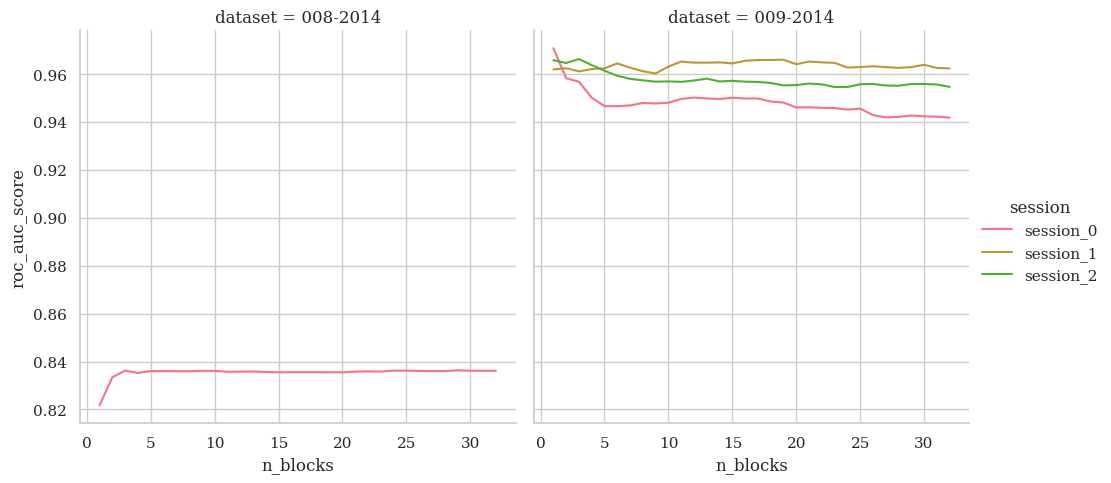

In [6]:
import seaborn as sns

df_agg = df.groupby(['dataset', 'subject', 'session', 'n_blocks'])
df_agg = df_agg.roc_auc_score.aggregate('mean')
df_agg = df_agg.reset_index()
sns.relplot(
    data=df_agg,
    col='dataset',
    #col_wrap=4,
    x='n_blocks',
    y='roc_auc_score',
    hue='session',
    kind="line",
    #units='subject',
    #estimator=None,
)